## Introduction

This project aims to build a machine learning model to classify chest X-ray images into two categories:
- Normal
- Pneumonia
The goal is to explore whether a model can automatically detect pneumonia from medical images.

### Project overview

The dataset is composed of chest X-ray images divided into:

training set
validation set
test set

### Why Logistic Regression?

Logistic Regression was chosen for several reasons:

- It is a simple and beginner-friendly model
- It is well adapted for binary classification
- It allows easy understanding of:
    - model behavior
    - overfitting
    - impact of preprocessing
- It provides a solid baseline before testing more complex models

This choice allows focusing on understanding the full machine learning pipeline before moving to more advanced models.

In [1]:
from t_dev_810.data.loader import load
from t_dev_810.utils import display_distribution, show_image_from_path, show_image_size, display_experiment_from_json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from typing import List



data = load()

## Data Visualization

### Class Distribution

The dataset is imbalanced, with significantly more pneumonia cases than normal cases.

This imbalance can bias the model toward predicting pneumonia more often. However, in a medical context, prioritizing the detection of pneumonia (high recall) is important.

The dataset is split into training, validation, and test sets. The validation set is relatively small, which may impact the reliability of hyperparameter tuning.

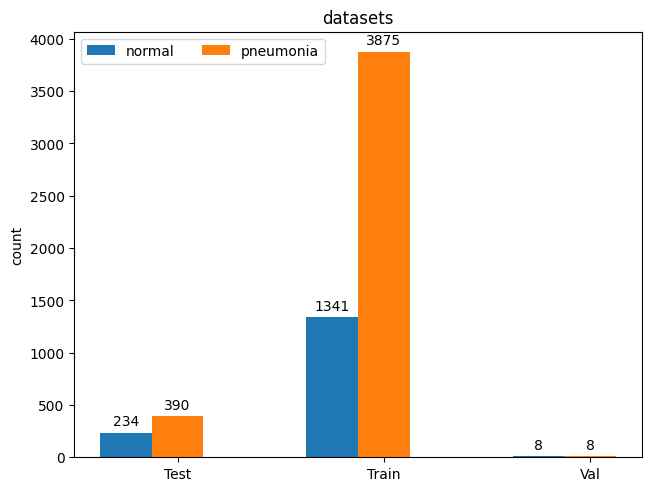

In [2]:
display_distribution(dataset=data)

### Sample Images

The images are grayscale chest X-rays.

We can observe visible differences between normal and pneumonia cases, particularly in lung opacity.

However, several challenges are present:
- Some images contain annotations or markers on the borders
- There is significant empty space and borders around the lungs
- Image quality and contrast vary across samples

These factors may introduce noise and affect model performance.

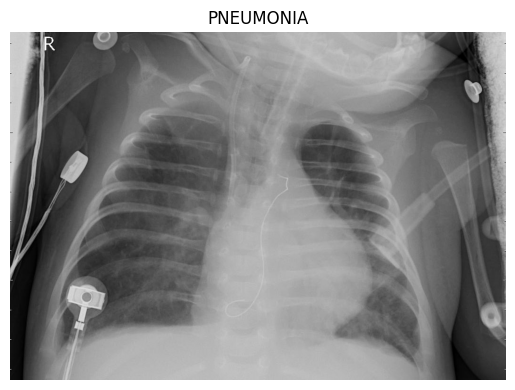

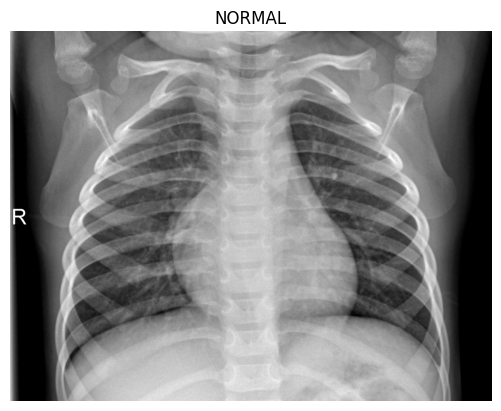

In [3]:
show_image_from_path(data.train[0].path, label=data.train[0].label)
show_image_from_path(data.train[-1].path, label=data.train[-1].label)

### Image Size Distribution

The dataset contains images with varying resolutions.

This inconsistency makes it necessary to resize all images to a fixed size before training.

Standardizing image dimensions ensures compatibility with machine learning models and improves training stability.

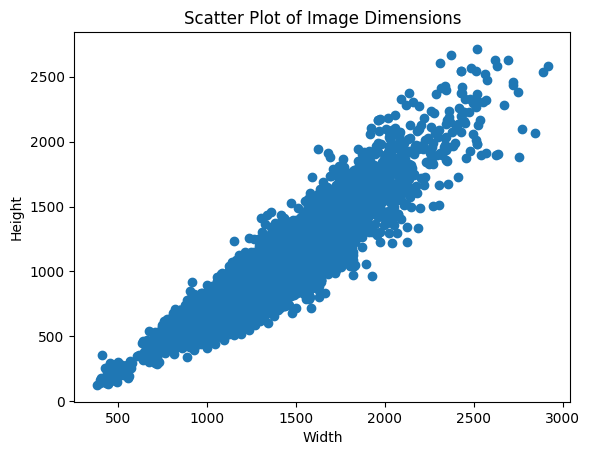

In [4]:
show_image_size(data)

### Conclusion

From this analysis, several important points emerge:

- The dataset is imbalanced, with more pneumonia cases than normal cases  
- The validation set is relatively small  
- Images have varying sizes and must be resized  
- Some images contain noise (annotations, borders)

To address these issues, the preprocessing pipeline will include:

- Image resizing to a fixed dimension  
- Cropping to remove unnecessary borders  
- Normalization of pixel values  

Additionally, the small size of the validation set may require adjusting the data split.

While the class imbalance may help prioritize pneumonia detection, it could also impact model generalization. If needed, techniques such as data augmentation or rebalancing may be explored.

# Preprocessing

## Overview

Before training the model, several preprocessing techniques were applied to improve data quality and model performance.

These steps aim to:
- standardize the input data
- reduce noise
- improve model generalization
- reduce overfitting

---

## Image Resizing

All images are resized to a fixed dimension.

**Why?**

The dataset contains images with different resolutions. Machine learning models require inputs of consistent size.

Resizing ensures:
- uniform input shape
- faster computation
- reduced complexity

However, reducing image size too much may lead to loss of important information.

---

## Image Cropping

Cropping is applied to remove borders around the images.

**Why?**

From dataset analysis, many images contain:
- unnecessary borders
- annotations or artifacts

Cropping helps:
- focus on relevant regions (lungs)
- reduce noise
- improve feature quality

---

## Color Enhancement

A color (contrast) enhancement factor can be applied.

**Why?**

Some images have low contrast, making patterns harder to detect.

Enhancement can:
- improve visibility of lung structures
- highlight differences between normal and pneumonia cases

However, excessive enhancement may distort the data.

---

## Normalization

Pixel values are normalized.

**Why?**

Raw pixel values range from 0 to 255. This scale can negatively impact model training.

Normalization:
- scales values to a smaller range (e.g. 0–1)
- stabilizes training
- improves convergence

---

## Dimensionality Reduction (PCA)

Principal Component Analysis (PCA) can be applied to reduce the number of features.

**Why?**

Images converted to vectors contain a large number of features.

PCA helps:
- reduce dimensionality
- remove noise
- reduce overfitting

However, too much reduction may remove useful information.

---

## Class Weight

Class weights can be adjusted to handle dataset imbalance.

**Why?**

The dataset contains more pneumonia cases than normal cases.

Using class weights allows:
- penalizing misclassification of minority class
- improving recall for underrepresented class

This is important in medical contexts where missing a disease is critical.

---

## Regularization

Regularization is controlled using parameter **C** and penalty type (L1, L2, ElasticNet).

**Why?**

Regularization helps prevent overfitting by constraining the model.

- **L2**: stabilizes weights  
- **L1**: performs feature selection  
- **ElasticNet**: combines both approaches  

The parameter **C** controls the strength of regularization.

---

## Solver Selection

Different solvers are used depending on the configuration.

**Why?**

Each solver has different properties:
- `lbfgs`: stable and efficient for L2  
- `liblinear`: good for small datasets  
- `saga`: supports L1 and ElasticNet  

Choosing the correct solver ensures compatibility and performance.

---

## Conclusion

These preprocessing steps are essential to improve model performance.

They allow:
- cleaning and standardizing the data  
- reducing noise and irrelevant information  
- controlling model complexity  

The impact of each step will be evaluated through experiments to determine the most effective configuration.

# Evaluation Metrics

To evaluate the model performance, several metrics were selected, with a particular focus on pneumonia detection.

---

## Choice of Metrics

Since the objective of this project is to detect pneumonia cases, **recall** is a key metric.

A high recall ensures that most pneumonia cases are correctly identified, which is critical in a medical context where missing a disease (false negative) can have serious consequences.

However, recall alone is not sufficient.

- A model predicting only "pneumonia" would achieve high recall but poor performance overall  
- Therefore, recall is combined with **precision** and **F1-score**

These metrics allow us to:
- evaluate the balance between false positives and false negatives  
- ensure the model is not biased toward predicting only one class  

---

## Selected Metrics

The following metrics are used:

- **Accuracy**: overall performance of the model  
- **Recall**: ability to detect pneumonia cases  
- **Precision**: reliability of positive predictions  
- **F1-score**: balance between precision and recall  
- **AUC (ROC)**: ability to separate classes  
- **Confusion Matrix**: detailed analysis of prediction errors  

---

## Overfitting Consideration

During experimentation, overfitting was identified as a major issue.

To monitor this, the following comparison is used:

- **Train AUC (cross-validation AUC)**
- **Test AUC**

A large difference between these values indicates that the model performs well on training data but fails to generalize.

---

## Confusion Matrix Analysis

The confusion matrix provides a detailed view of prediction errors:

- **True Positives (TP)**: correctly detected pneumonia cases  
- **False Positives (FP)**: normal cases predicted as pneumonia  
- **True Negatives (TN)**: correctly detected normal cases  
- **False Negatives (FN)**: missed pneumonia cases  

In this context, minimizing **false negatives** is particularly important, as they represent undetected pneumonia cases.

---

## Conclusion

The evaluation strategy focuses on balancing:

- high recall (to detect pneumonia cases)  
- acceptable precision (to avoid too many false alarms)  
- good generalization (by comparing train and test AUC)  

This combination of metrics provides a more complete and reliable evaluation of the model performance.

# Experiments

In this section, multiple experiments are conducted to evaluate the impact of different preprocessing techniques and model configurations.

Each experiment includes:
- a hypothesis
- selected parameters
- results
- analysis

### First hypothsis


## 🧪 Experiment — 2026-03-30T20:50:15.973318

### Hypothesis
first try to have result reference with default config

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: False
- **Max iter**: 2000

### Results


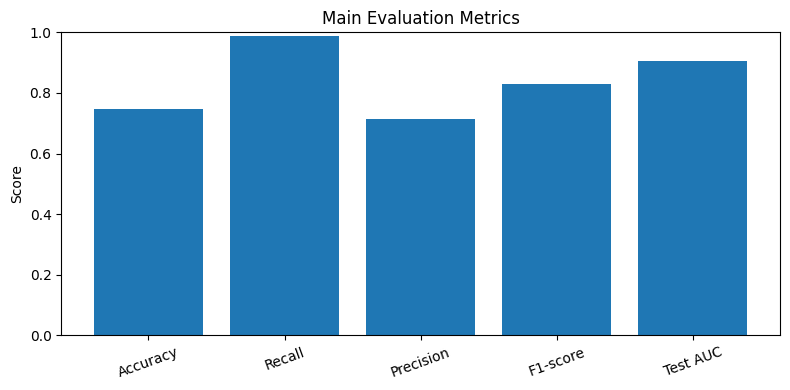

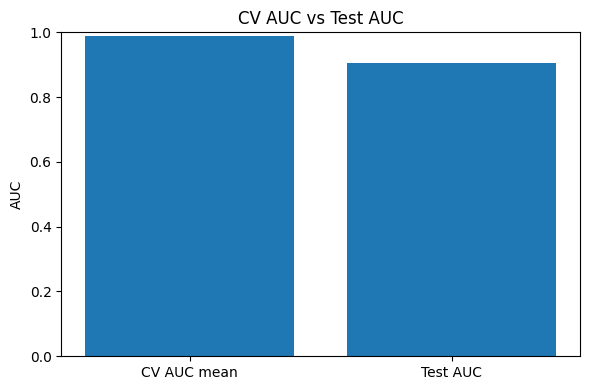

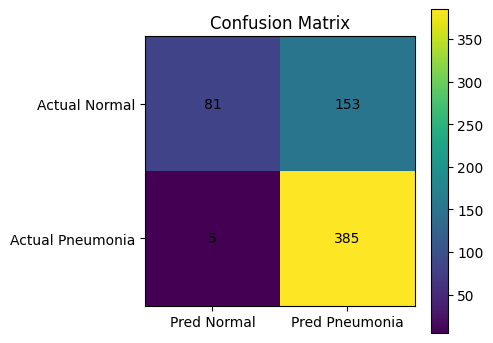

In [5]:
display_experiment_from_json('2026-03-30T20:50:15.973318')